In [11]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

path = "../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"

In [12]:
rna_hl_human = np.load( path + 'rna_hl_human.npz')

print(rna_hl_human.files)

print("\nArray shapes:")
print(f"X shape: {rna_hl_human['X'].shape}")
print(f"y shape: {rna_hl_human['y'].shape}")
print(f"genes shape: {rna_hl_human['genes'].shape}")

print(f"\nX dimensions: {rna_hl_human['X'].ndim}")
if rna_hl_human['X'].ndim == 3:
    print(f"X first sample shape: {rna_hl_human['X'][0].shape}")
    print(f"X first sample, first feature vector: {rna_hl_human['X'][0, 0, :5]}")  # First 5 features
elif rna_hl_human['X'].ndim == 2:
    print(f"X first sample (first 10 features): {rna_hl_human['X'][0, :10]}")


['X', 'y', 'genes']

Array shapes:
X shape: (12968, 12288, 6)
y shape: (12968,)
genes shape: (12968,)

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 1. 0. 0. 0.]


In [13]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [14]:
# Flatten X: (num_genes, 12288, 6) -> (num_genes, 12288*6)
X_flat = rna_hl_human['X'].reshape(rna_hl_human['X'].shape[0], -1)

# Run PCA
n_components = 1024  # or any number you want
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_flat)

# Create DataFrame with genes as index and PCA embeddings as columns
genes = rna_hl_human['genes']
column_names = [f'PCA_{i}' for i in range(n_components)]
df_pca = pd.DataFrame(X_pca, columns=column_names)
df_pca['gene_id'] = genes
df_pca = df_pca.set_index('gene_id')

print(df_pca.shape)

(12968, 1024)


In [15]:
total_explained_variance = np.sum(pca.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 44.54%


In [16]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene"]]
merged = df_pca.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023,NCG_Known_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
M6PR,-8.237757,-1.800412,9.178756,2.385722,2.096804,0.131452,4.832361,-6.338816,2.323429,0.591539,...,-0.205405,-1.080478,0.376234,-0.310098,-0.156473,0.614052,-0.990964,1.058224,-0.873192,False
CAMKK1,-2.776514,-2.949918,15.923935,7.525376,2.525763,-0.079138,8.388812,-3.421884,-0.973065,-5.601458,...,0.998870,0.017821,0.392931,0.097363,1.491900,0.263091,1.162210,-0.474109,-0.921244,False
RECQL,0.973839,-3.971152,17.951122,9.836308,1.754825,-0.029418,-1.073791,-5.399292,-4.254445,5.011054,...,0.825665,-0.237225,0.056873,0.525126,-0.350800,0.728883,-0.872258,0.180453,0.336534,False
SLC25A5,-14.954939,-6.669129,-6.679528,-8.113275,-5.335100,6.026334,-3.364634,2.998498,-2.957490,0.411889,...,-0.295447,-0.421027,0.159451,-0.561818,-0.314591,-0.096888,0.013163,-0.196076,-0.640467,False
HOXA11,-10.878610,9.096770,-3.440986,-2.067759,3.795748,-5.674836,-4.199334,-0.670108,3.291527,-0.986968,...,-0.862221,-0.115618,0.335349,0.588003,-0.186377,-0.757788,-0.151186,-0.050515,-0.816479,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL4,-15.734590,-0.233591,2.474291,-9.345870,-6.181187,-1.417937,2.460636,3.264165,-5.534035,-0.218951,...,-0.438526,0.228560,0.206409,0.017041,-0.016947,-0.215630,-0.085136,-0.060989,-0.294702,False
TUBGCP5,2.122150,-18.301886,-15.866838,9.272806,4.941951,-1.461128,1.816379,-0.377459,-4.907488,5.436591,...,-0.236554,0.668351,-0.436427,0.195449,-0.597363,-0.605098,-0.221944,-0.249504,-0.331340,False
UHRF1,3.821121,-17.756536,-14.319707,10.505559,3.448287,2.316641,0.060968,2.354952,-3.479988,-3.825341,...,1.522718,-0.491818,0.695989,-0.471457,-0.238849,-0.546172,0.095306,0.865915,-0.398582,False


In [17]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    9724
True      572
Name: count, dtype: int64

/opt/modules/i12g/anaconda/envs/ege_env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [18:46:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


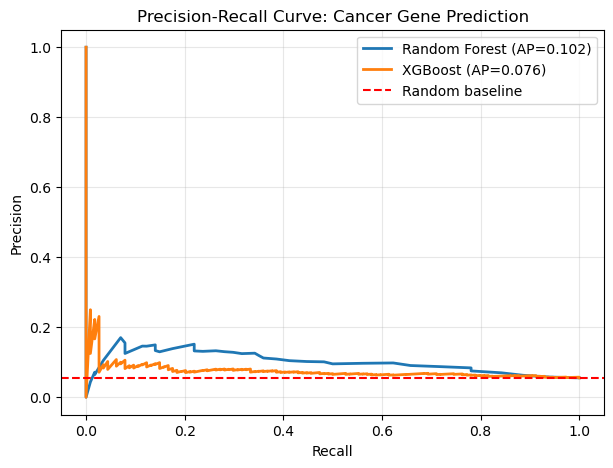

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd

# Add XGBoost
from xgboost import XGBClassifier

# Prepare features and target
X = merged.drop('NCG_Known_Cancer_Gene', axis=1)
y = merged['NCG_Known_Cancer_Gene']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train Random Forest
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train, y_train)
y_prob_rf = clf_rf.predict_proba(X_test)[:, 1]

# Train XGBoost
clf_xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
clf_xgb.fit(X_train, y_train)
y_prob_xgb = clf_xgb.predict_proba(X_test)[:, 1]

# Precision-recall curves
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
ap_score_rf = average_precision_score(y_test, y_prob_rf)

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
ap_score_xgb = average_precision_score(y_test, y_prob_xgb)

plt.figure(figsize=(7, 5))
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP={ap_score_rf:.3f})', linewidth=2)
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP={ap_score_xgb:.3f})', linewidth=2)
plt.axhline(y=sum(y_test)/len(y_test), color='red', linestyle='--', label='Random baseline')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Cancer Gene Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()